In [53]:
import json
import pandas as pd
import folium
from folium.plugins import HeatMap
import os

# --- Configuration ---
# Make sure these match your generation script!
OUTPUT_FILE = "bar_density_grid.json"
FINAL_LAT_STEP = 2.0
FINAL_LON_STEP = 2.0
# ---------------------

In [56]:
print(f"Loading data from {OUTPUT_FILE}...")

# Calculate the offset to find the center of each grid cell
# This is better for a heatmap than plotting the corner.
lat_offset = FINAL_LAT_STEP / 2
lon_offset = FINAL_LON_STEP / 2

data_list = []
total_bars = 0
file_exists = os.path.exists(OUTPUT_FILE)

if file_exists:
    try:
        with open(OUTPUT_FILE, 'r') as f:
            # We read the file content first to handle the case of an empty file
            content = f.read()
            if not content:
                print("File is empty. (This is normal if the script just started).")
                data_dict = {}
            else:
                data_dict = json.loads(content)
        
        # Process the loaded data
        for key, count in data_dict.items():
            # We only need to plot cells that have bars
            if count > 0:
                try:
                    lat_s, lon_w = key.split('_')
                    
                    # Calculate cell center
                    lat_center = float(lat_s) + lat_offset
                    lon_center = float(lon_w) + lon_offset
                    
                    data_list.append([lat_center, lon_center, count])
                    total_bars += count
                
                except (ValueError, TypeError):
                    print(f"Skipping malformed key in JSON: {key}")

        if data_list:
            print(f"Loaded and processed {len(data_list):,} non-zero grid cells.")
            print(f"Total bars found so far: {total_bars:,}")
        else:
            print("File loaded, but no bar data found yet.")

    except json.JSONDecodeError:
        print("Error: Could not parse JSON. The file might be corrupt or being written to.")
        print("Try running this cell again in a few seconds.")
        data_list = [] # Ensure we don't proceed with partial data
    
    except FileNotFoundError:
         # This case is now handled by os.path.exists, but good to keep
         print("File not found. Please run the generation script.")
         data_list = []
else:
    print(f"File '{OUTPUT_FILE}' not found. (This is normal if the script hasn't run yet).")

# Create a DataFrame for easy handling
df = pd.DataFrame(data_list, columns=['lat', 'lon', 'count'])

if not df.empty:
    display(df.describe())
else:
    print("No data to display.")

Loading data from bar_density_grid.json...
Loaded and processed 2,572 non-zero grid cells.
Total bars found so far: 352,817


,lat,lon,count
count,2572.000000,2572.000000,2572.000000
mean,20.831260,14.192068,137.176128
std,30.446814,81.979072,512.865292
min,-75.000000,-175.000000,1.000000
25%,-3.000000,-63.000000,3.000000
50%,27.000000,22.000000,12.000000
75%,47.000000,77.500000,59.000000
max,79.000000,179.000000,11733.000000


In [57]:
if not df.empty:
    print("Generating heatmap...")
    
    # Create a base map, centered roughly on Europe
    m = folium.Map(location=[45, 15], zoom_start=3, tiles="CartoDB positron")

    # Prepare the data for the HeatMap plugin
    # It needs a list of [lat, lon, weight]
    heat_data = df[['lat', 'lon', 'count']].values.tolist()

    # Create and add the heatmap layer
    HeatMap(
        data=heat_data,
        radius=12,  # Adjust radius to your liking
        blur=10,     # Adjust blur
        max_zoom=1,
    ).add_to(m)

    # Add a layer control to toggle the heatmap on/off
    folium.LayerControl().add_to(m)

    # Display the map in the notebook
    display(m)
    
else:
    print("Cannot create map: No data is available.")
    print("Run your generation script and re-run the cells above.")

Generating heatmap...


In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
# Make sure these match your generation script!
OUTPUT_FILE = "bar_density_grid_1x1.json"
FINAL_LAT_STEP = 1.0
FINAL_LON_STEP = 1.0

# Globe boundaries
LAT_MIN, LAT_MAX = -90.0, 90.0
LON_MIN, LON_MAX = -180.0, 180.0
# ---------------------

In [9]:
print(f"Loading data from {OUTPUT_FILE}...")

# Calculate grid dimensions
n_lat = int((LAT_MAX - LAT_MIN) / FINAL_LAT_STEP)
n_lon = int((LON_MAX - LON_MIN) / FINAL_LON_STEP)

# Create a grid filled with np.nan
# np.nan is useful so we can color "unprocessed" cells differently
grid_data = np.full((n_lat, n_lon), np.nan)

total_bars = 0
cells_processed = 0

# --- Load data safely ---
if not os.path.exists(OUTPUT_FILE):
    print(f"File '{OUTPUT_FILE}' not found. (This is normal if the script hasn't run yet).")
else:
    try:
        with open(OUTPUT_FILE, 'r') as f:
            content = f.read()
            if not content:
                print("File is empty. (This is normal if the script just started).")
                data_dict = {}
            else:
                data_dict = json.loads(content)
        
        # --- Populate the numpy grid ---
        for key, count in data_dict.items():
            try:
                lat_s, lon_w = key.split('_')
                lat_s, lon_w = float(lat_s), float(lon_w)
                
                # Convert lat/lon to grid indices
                # We flip latitude so 0 is the North Pole (top of the image)
                i = (n_lat - 1) - int((lat_s - LAT_MIN) / FINAL_LAT_STEP)
                j = int((lon_w - LON_MIN) / FINAL_LON_STEP)
                
                if 0 <= i < n_lat and 0 <= j < n_lon:
                    grid_data[i, j] = count
                    if count > 0:
                        total_bars += count
                    cells_processed += 1
                
            except (ValueError, TypeError):
                print(f"Skipping malformed key in JSON: {key}")

        print(f"Loaded and processed {cells_processed:,} grid cells.")
        print(f"Total bars found so far: {total_bars:,}")

    except json.JSONDecodeError:
        print("Error: Could not parse JSON. The file might be corrupt or being written to.")
        print("Try running this cell again in a few seconds.")

Loading data from bar_density_grid_1x1.json...
Loaded and processed 20,042 grid cells.
Total bars found so far: 4,401


Generating simple 2D heatmap...


C:\Users\benja\AppData\Local\Temp\ipykernel_8692\2260895013.py:17: RuntimeWarning: divide by zero encountered in log
  np.log(grid_data),


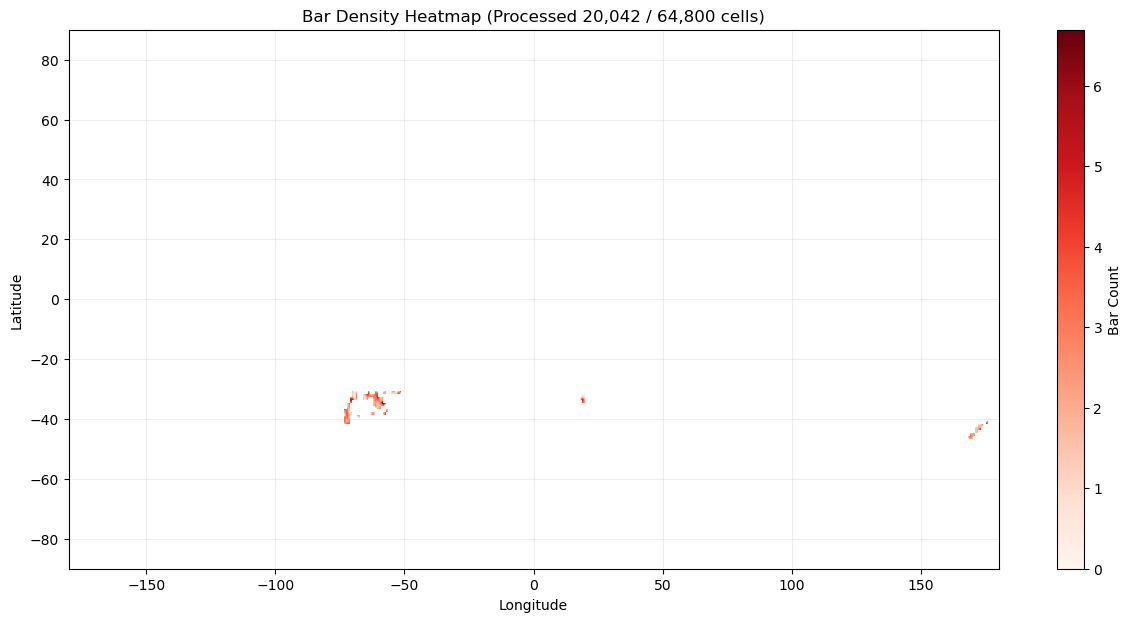

In [10]:
if cells_processed > 0:
    print("Generating simple 2D heatmap...")
    
    # Get a colormap (e.g., 'inferno', 'hot', 'jet')
    # We'll use 'inferno' as dark colors = 0, bright colors = high count
    cmap = plt.get_cmap('Reds')
    
    # Set the color for "bad" values (our np.nan cells)
    cmap.set_bad(color='gray', alpha=0.0)

    # Plot the grid
    plt.figure(figsize=(15, 7))
    
    # We use vmin=0 so that 0-count cells (empty land/ocean) are
    # colored black (the bottom of 'inferno'), not nan-gray.
    im = plt.imshow(
        np.log(grid_data), 
        cmap=cmap, 
        vmin=0, 
        extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], 
        aspect='auto'
    )
    
    plt.colorbar(im, label='Bar Count')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Bar Density Heatmap (Processed {cells_processed:,} / {n_lat*n_lon:,} cells)')
    plt.grid(alpha=0.2)
    plt.show()

else:
    print("No data to plot. Run the generation script and re-run the cells above.")

In [11]:
grid_data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

Generating simple 2D heatmap...


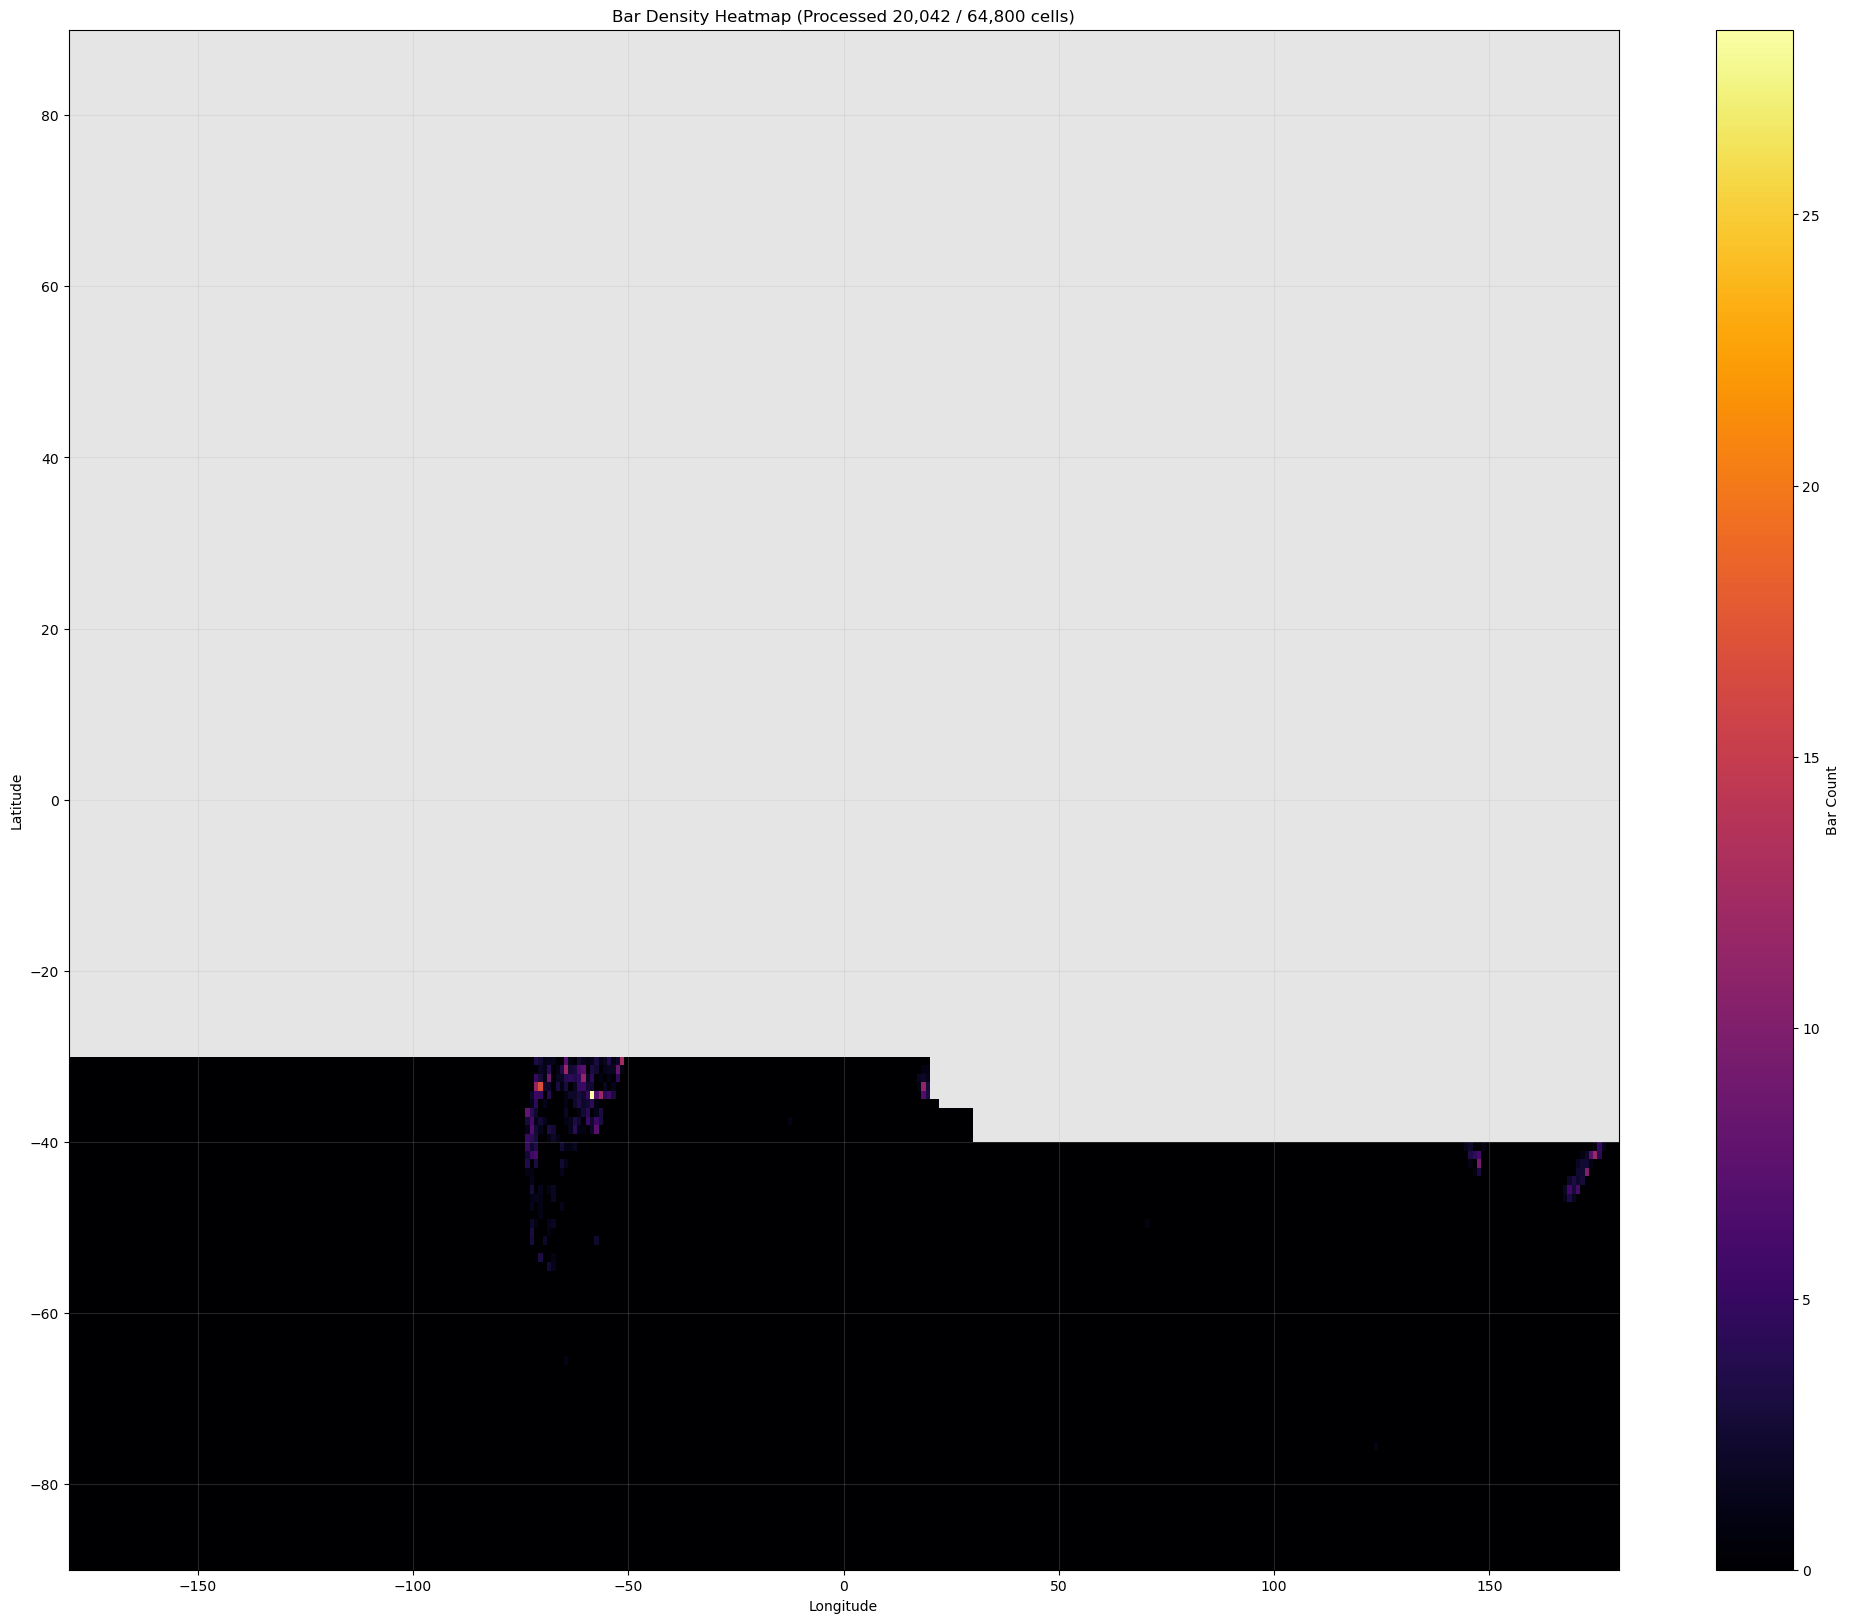

In [12]:
if cells_processed > 0:
    print("Generating simple 2D heatmap...")
    
    # Get a colormap (e.g., 'inferno', 'hot', 'jet')
    # We'll use 'inferno' as dark colors = 0, bright colors = high count
    cmap = plt.get_cmap('inferno')
    
    # Set the color for "bad" values (our np.nan cells)
    cmap.set_bad(color='gray', alpha=0.2)

    # Plot the grid
    plt.figure(figsize=(25, 20))
    
    # We use vmin=0 so that 0-count cells (empty land/ocean) are
    # colored black (the bottom of 'inferno'), not nan-gray.
    im = plt.imshow(
        grid_data**0.5, 
        cmap=cmap, 
        vmin=0, 
        vmax=None,
        extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], 
        aspect='auto'
    )
    
    plt.colorbar(im, label='Bar Count')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Bar Density Heatmap (Processed {cells_processed:,} / {n_lat*n_lon:,} cells)')
    plt.grid(alpha=0.2)
    plt.show()

else:
    print("No data to plot. Run the generation script and re-run the cells above.")

Generating 3D bar plot...


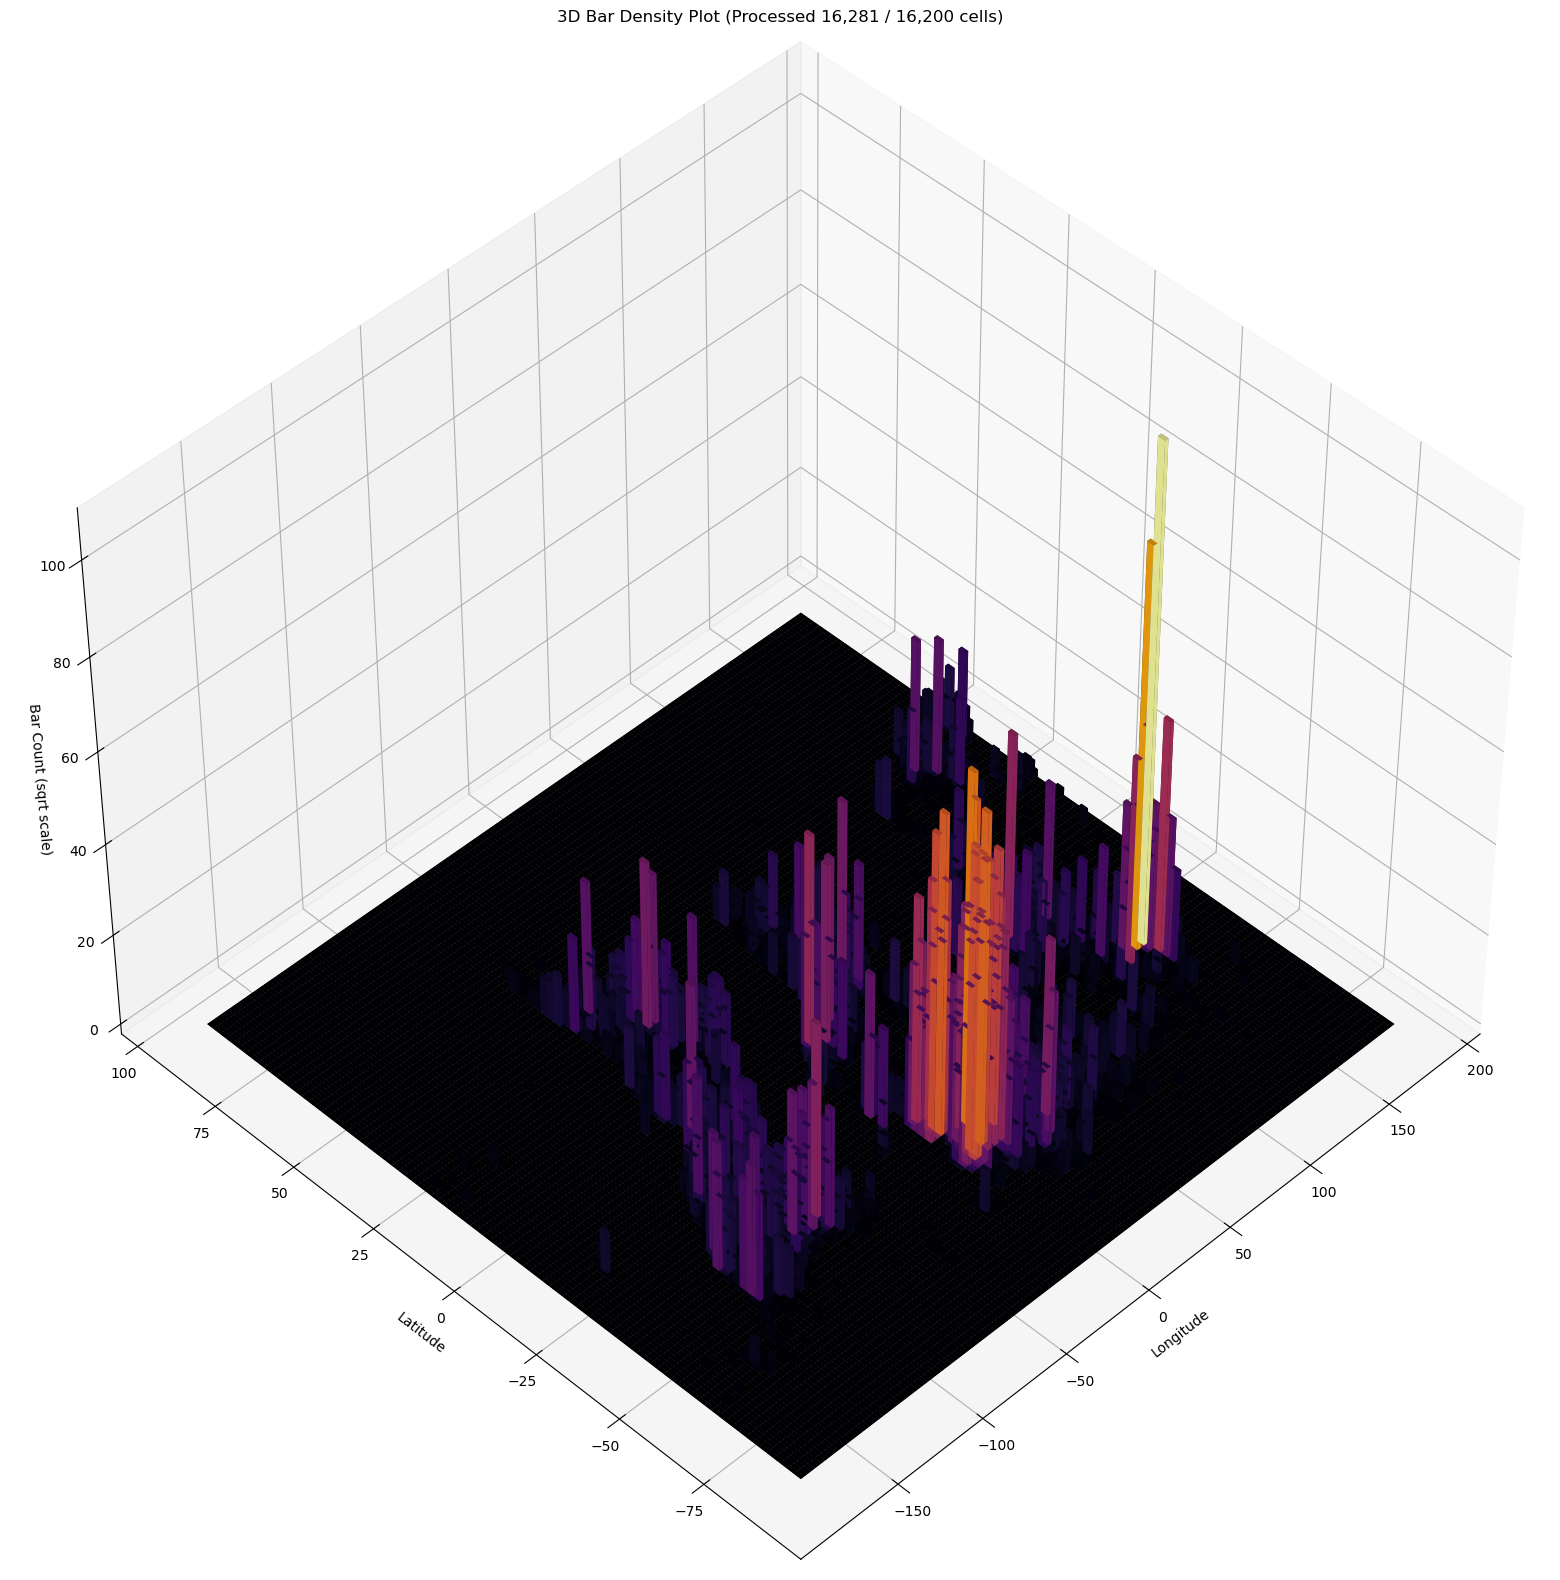

In [77]:
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

if cells_processed > 0:
    print("Generating 3D bar plot...")

    # Prepare coordinate grid
    lon = np.linspace(LON_MIN, LON_MAX, n_lon)
    lat = np.linspace(LAT_MIN, LAT_MAX, n_lat)
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Flatten data for bar3d
    x = lon_grid.ravel()
    y = lat_grid.ravel()
    z = np.zeros_like(x)
    dz = np.nan_to_num(grid_data.ravel() ** 0.5, nan=0.0)  # Replace NaNs with zero

    # Bar dimensions
    dx = (LON_MAX - LON_MIN) / n_lon
    dy = (LAT_MAX - LAT_MIN) / n_lat

    # Color map (use same as before)
    cmap = plt.get_cmap('inferno')
    colors = cmap((dz - dz.min()) / (dz.max() - dz.min() + 1e-9))

    # Create figure
    fig = plt.figure(figsize=(25, 20))
    ax = fig.add_subplot(111, projection='3d')

    # Plot bars
    ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)

    # Labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_zlabel('Bar Count (sqrt scale)')
    ax.set_title(f'3D Bar Density Plot (Processed {cells_processed:,} / {n_lat*n_lon:,} cells)')

    # Adjust view angle
    ax.view_init(elev=45, azim=225)

    plt.show()

else:
    print("No data to plot. Run the generation script and re-run the cells above.")